In [ ]:
# Three kinds of errors most happened in PyTorch
# 1. Shape Error. Dimension Mismatches.
# 2. Data Type Error. Incorrect Tensor Types.
# 3. Device Error. CPU/GPU Issues.

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


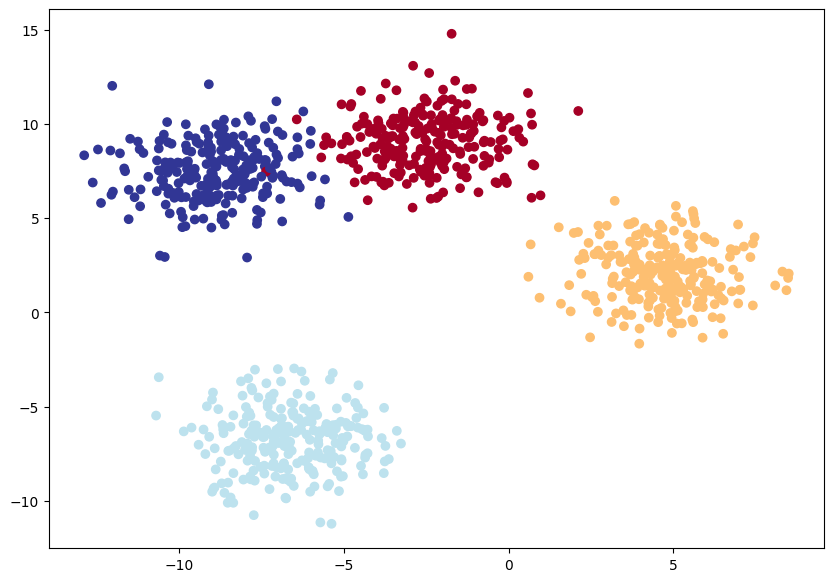

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FETURES = 2
RANDOM_SEED = 42

# 1. Create multi-calss data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FETURES,  # X Features
                            centers=NUM_CLASSES,     # y labels
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train an test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# 4. Plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)

In [ ]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from torch import nn

# Build model
class BlobModelV0(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """Initializes all required hyperparameters for a muti-class classification problem.

    Args:
      input_features(int): Number of input features to the model.
      output_features(int): Number of output features of the model.
      hidden_units(int): Number of hidden units between layers, default 8.
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
          nn.Linear(in_features=input_features, out_features=hidden_units),
          nn.ReLU(),
          nn.Linear(in_features= hidden_units, out_features=hidden_units),
          nn.ReLU(),
          nn.Linear(in_features=hidden_units, out_features=output_features),
      )
  def forward(self, x):
    return self.linear_layer_stack(x)

# Creat an instance of BlobModel and send it to the target device
model_4 = BlobModelV0(input_features=NUM_FETURES,
                      output_features=NUM_CLASSES,
                      hidden_units=8).to(device)
model_4

BlobModelV0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                             lr=0.1)

In [ ]:
# Perform a single forward pass on the data
model_4(X_blob_train.to(device))[:5]

tensor([[-0.4130,  0.5097, -0.5486,  0.1857],
        [ 0.1116,  1.3080, -1.1959,  0.5507],
        [ 0.7619,  1.0031, -0.2659,  0.3122],
        [ 0.5584,  0.9415, -0.3026,  0.1711],
        [ 0.2799,  1.2278, -0.9910,  0.4077]], grad_fn=<SliceBackward0>)

In [ ]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [ ]:
# Make prediciton logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimenson 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.4613,  0.5285, -0.5956,  0.1895],
        [ 1.0174,  1.8126, -1.3742,  0.2954],
        [ 0.5474,  0.6844, -0.0774,  0.2535],
        [-0.2006,  0.3555, -0.2932,  0.0821],
        [-0.3102,  1.0618, -1.0852,  0.5798]], grad_fn=<SliceBackward0>)
tensor([[0.1543, 0.4151, 0.1349, 0.2958],
        [0.2637, 0.5841, 0.0241, 0.1281],
        [0.2917, 0.3346, 0.1562, 0.2175],
        [0.2007, 0.3500, 0.1830, 0.2663],
        [0.1276, 0.5030, 0.0588, 0.3106]], grad_fn=<SliceBackward0>)


In [ ]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[0])

tensor(1.0000, grad_fn=<SumBackward0>)

In [ ]:
# Which class dose the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.1543, 0.4151, 0.1349, 0.2958], grad_fn=<SelectBackward0>)
tensor(1)


In [ ]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.74511, Acc: 26.12% | Test Loss: 1.27891, Test Acc: 35.50%
Epoch: 10 | Loss: 0.40489, Acc: 98.38% | Test Loss: 0.33079, Test Acc: 99.00%
Epoch: 20 | Loss: 0.14603, Acc: 99.25% | Test Loss: 0.12290, Test Acc: 99.50%
Epoch: 30 | Loss: 0.08218, Acc: 99.12% | Test Loss: 0.06941, Test Acc: 99.50%
Epoch: 40 | Loss: 0.05983, Acc: 99.12% | Test Loss: 0.04946, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04918, Acc: 99.12% | Test Loss: 0.03958, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04311, Acc: 99.12% | Test Loss: 0.03376, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03924, Acc: 99.12% | Test Loss: 0.02996, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03658, Acc: 99.12% | Test Loss: 0.02728, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03465, Acc: 99.12% | Test Loss: 0.02530, Test Acc: 99.50%


In [ ]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[ 0.0680,  5.6676, -4.6476, -5.6622],
        [ 4.4861, -3.3042,  0.7636,  9.9861],
        [-3.1498, -2.2212,  7.2201,  0.8544],
        [-0.4591,  3.8566, -2.6052, -3.6101],
        [ 7.3629,  2.3235, -7.8858, -1.4505],
        [ 5.1697, -3.9587,  1.0001, 11.8312],
        [-2.6986, -1.8462,  6.2299,  0.6583],
        [ 7.5103,  0.6798, -6.5759,  0.4416],
        [-3.9838, -2.8664,  9.0101,  1.1531],
        [ 7.3470,  1.2476, -6.9163, -0.2398]])

In [ ]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Test accuracy: 99.5%


In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

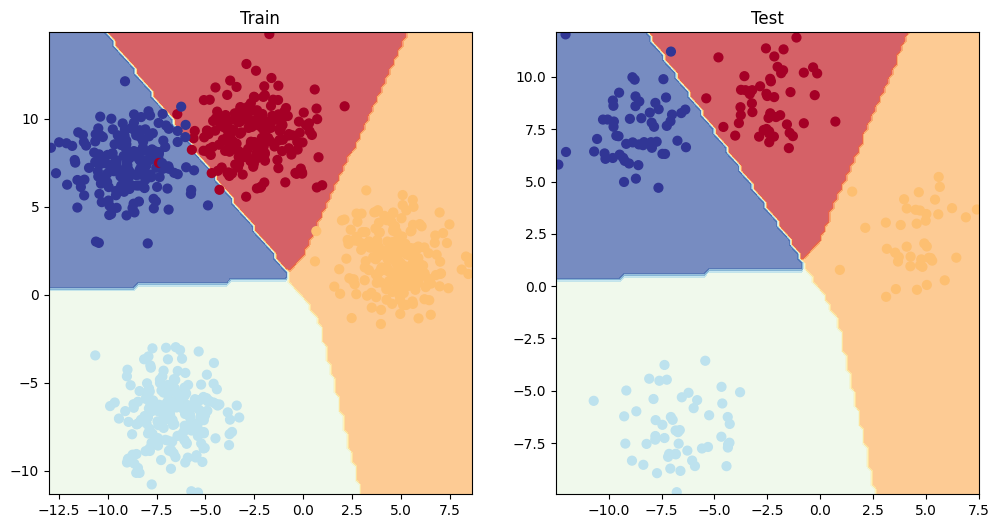

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)